# Assignment 1 Debug

In [1]:
# import
import sys

import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append("..")

from utils.data import get_dataloaders


In [2]:
# data loading
mnist = get_dataloaders("mnist", batch_size=64, data_root="../data")
cifar10 = get_dataloaders("cifar10", batch_size=64, data_root="../data")
cifar10_preprocess = get_dataloaders(
    "cifar10",
    batch_size=64,
    data_root="../data",
    use_preprocess=True,
)

for dataset in tqdm([mnist, cifar10, cifar10_preprocess], desc="datasets"):
    images, labels = next(iter(dataset["train_loader"]))
    print(dataset["dataset_name"], "preprocess" if dataset["use_preprocess"] else "")
    print("data root:", dataset["data_root"])
    print("classes:", dataset["num_classes"])
    print("input shape:", dataset["input_shape"])
    print("image batch:", tuple(images.shape))
    print("label batch:", tuple(labels.shape))
    print()


/home/ahy0502/anaconda3/envs/trustworthy-ai-a1/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
datasets: 100%|██████████| 3/3 [00:00<00:00, 11.76it/s]

mnist 
data root: ../data/mnist
classes: 10
input shape: (1, 28, 28)
image batch: (64, 1, 28, 28)
label batch: (64,)

cifar10 
data root: ../data/cifar10
classes: 10
input shape: (3, 32, 32)
image batch: (64, 3, 32, 32)
label batch: (64,)

cifar10 preprocess
data root: ../data/cifar10
classes: 10
input shape: (3, 224, 224)
image batch: (64, 3, 224, 224)
label batch: (64,)



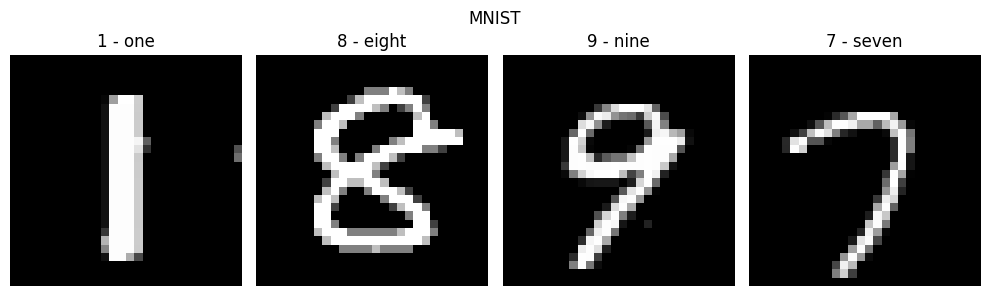

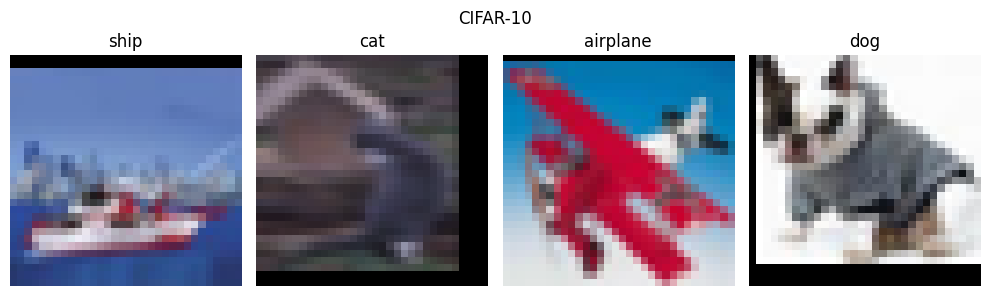

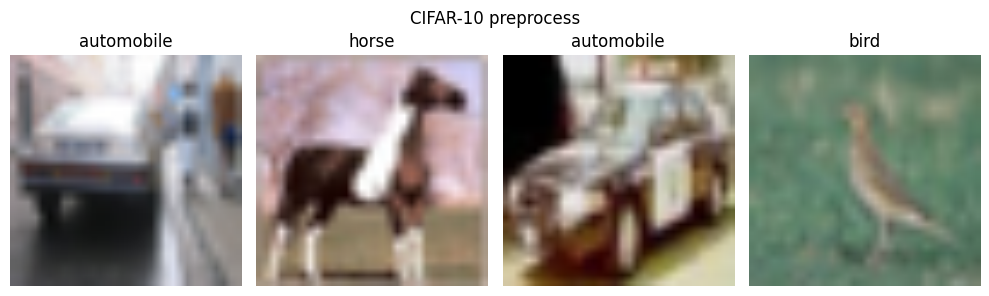

In [3]:
# data visualize
def show_batch(dataset, title):
    images, labels = next(iter(dataset["train_loader"]))
    images = images[:8]
    labels = labels[:8]

    fig, axes = plt.subplots(1, 4, figsize=(10, 3))
    axes = axes.flatten()

    for ax, image, label in zip(axes, images, labels):
        if image.shape[0] == 1:
            ax.imshow(image.squeeze(0), cmap="gray")
        else:
            ax.imshow(image.permute(1, 2, 0))
        ax.set_title(dataset["class_names"][int(label)])
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(mnist, "MNIST")
show_batch(cifar10, "CIFAR-10")
show_batch(cifar10_preprocess, "CIFAR-10 preprocess")


In [4]:
# MNIST model
from models.mnist_cnn import MNISTCNN

mnist_model = MNISTCNN(
    use_dropout=False,
    use_bn=False,
    use_gelu=False,
    use_softmax=False,
)

mnist_images, mnist_labels = next(iter(mnist["train_loader"]))
mnist_logits = mnist_model(mnist_images)

print(mnist_model)
print("input batch:", tuple(mnist_images.shape))
print("output batch:", tuple(mnist_logits.shape))


MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Identity()
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Identity()
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): Identity()
    (3): ReLU(inplace=True)
    (4): Identity()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
  (out): Identity()
)
input batch: (64, 1, 28, 28)
output batch: (64, 10)


In [5]:
# MNIST training / accuracy
import torch

from utils.train import train_classifier

mnist_device = torch.device(
    "cuda:4"
    if torch.cuda.is_available() and torch.cuda.device_count() > 4
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
mnist_epochs = 3
mnist_lr = 1e-3

mnist_model, mnist_history = train_classifier(
    mnist_model,
    mnist["train_loader"],
    mnist["test_loader"],
    device=mnist_device,
    epochs=mnist_epochs,
    lr=mnist_lr,
)

print("device:", mnist_device)
print("final train loss:", f"{mnist_history['train_loss'][-1]:.4f}")
print("final train acc:", f"{mnist_history['train_acc'][-1]:.4f}")
print("final clean test acc:", f"{mnist_history['test_acc'][-1]:.4f}")


eval 1/3: 100%|██████████| 157/157 [00:00<00:00, 283.15it/s, acc=0.9848]


epoch 1: train_loss=0.1837, train_acc=0.9438, test_acc=0.9848


eval 2/3: 100%|██████████| 157/157 [00:00<00:00, 266.46it/s, acc=0.9872]


epoch 2: train_loss=0.0536, train_acc=0.9837, test_acc=0.9872


eval 3/3: 100%|██████████| 157/157 [00:00<00:00, 258.59it/s, acc=0.9900]

epoch 3: train_loss=0.0370, train_acc=0.9884, test_acc=0.9900
device: cuda:4
final train loss: 0.0370
final train acc: 0.9884
final clean test acc: 0.9900


In [6]:
# CIFAR-10 model
from models.cifar_resnet import CIFARResNet

use_pretrained = False
use_gelu = False
use_softmax = False

dataset = cifar10_preprocess if use_pretrained else cifar10

model = CIFARResNet(
    use_pretrained=use_pretrained,
    use_gelu=use_gelu,
    use_softmax=use_softmax,
)

images, labels = next(iter(dataset["train_loader"]))
logits = model(images)

print(model)
print("use_pretrained:", use_pretrained)
print("dataset:", "cifar10_preprocess" if use_pretrained else "cifar10")
print("input batch:", tuple(images.shape))
print("output batch:", tuple(logits.shape))


CIFARResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): Identity()
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
       

In [7]:
# CIFAR-10 training / accuracy
import torch

from utils.train import train_classifier

model = model
dataset = dataset
device = torch.device(
    "cuda:4"
    if torch.cuda.is_available() and torch.cuda.device_count() > 4
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

if use_pretrained:
    epochs = 3
    lr = 1e-4
else:
    epochs = 10
    lr = 1e-3

model, history = train_classifier(
    model,
    dataset["train_loader"],
    dataset["test_loader"],
    device=device,
    epochs=epochs,
    lr=lr,
)

print("device:", device)
print("epochs:", epochs)
print("lr:", lr)
print("final train loss:", f"{history['train_loss'][-1]:.4f}")
print("final train acc:", f"{history['train_acc'][-1]:.4f}")
print("final clean test acc:", f"{history['test_acc'][-1]:.4f}")


eval 1/10: 100%|██████████| 157/157 [00:00<00:00, 157.48it/s, acc=0.6100]


epoch 1: train_loss=1.3562, train_acc=0.5062, test_acc=0.6100


eval 2/10: 100%|██████████| 157/157 [00:01<00:00, 142.39it/s, acc=0.6695]


epoch 2: train_loss=0.8817, train_acc=0.6880, test_acc=0.6695


eval 3/10: 100%|██████████| 157/157 [00:01<00:00, 139.17it/s, acc=0.7271]


...

epoch 8: train_loss=0.3591, train_acc=0.8745, test_acc=0.8585


eval 9/10: 100%|██████████| 157/157 [00:01<00:00, 137.23it/s, acc=0.8594]


epoch 9: train_loss=0.3344, train_acc=0.8864, test_acc=0.8594


eval 10/10: 100%|██████████| 157/157 [00:01<00:00, 138.87it/s, acc=0.8758]

epoch 10: train_loss=0.3053, train_acc=0.8944, test_acc=0.8758
device: cuda:4
epochs: 10
lr: 0.001
final train loss: 0.3053
final train acc: 0.8944
final clean test acc: 0.8758


In [9]:
# MNIST FGSM check
from attacks.fgsm import fgsm_targeted, fgsm_untargeted
from attacks.pgd import pgd_targeted, pgd_untargeted
from utils.eval_attack import eval_attack_targeted, eval_attack_untargeted

mnist_attack_samples = 5000
mnist_fgsm_eps = 0.3

mnist_fgsm_targeted, mnist_fgsm_targeted_time = eval_attack_targeted(
    mnist_model,
    mnist["test_loader"],
    fgsm_targeted,
    device=mnist_device,
    num_classes=mnist["num_classes"],
    num_samples=mnist_attack_samples,
    desc="mnist fgsm targeted",
    eps=mnist_fgsm_eps,
)

mnist_fgsm_untargeted, mnist_fgsm_untargeted_time = eval_attack_untargeted(
    mnist_model,
    mnist["test_loader"],
    fgsm_untargeted,
    device=mnist_device,
    num_samples=mnist_attack_samples,
    desc="mnist fgsm untargeted",
    eps=mnist_fgsm_eps,
)

print("mnist fgsm eps:", mnist_fgsm_eps)
print("mnist fgsm targeted success rate:", f"{mnist_fgsm_targeted:.4f}")
print("mnist fgsm targeted time:", f"{mnist_fgsm_targeted_time:.2f}s")
print("mnist fgsm untargeted success rate:", f"{mnist_fgsm_untargeted:.4f}")
print("mnist fgsm untargeted time:", f"{mnist_fgsm_untargeted_time:.2f}s")


mnist fgsm untargeted:  50%|█████     | 79/157 [00:00<00:00, 174.06it/s, success_rate=0.9412]

mnist fgsm eps: 0.3
mnist fgsm targeted success rate: 0.3634
mnist fgsm targeted time: 0.58s
mnist fgsm untargeted success rate: 0.9412
mnist fgsm untargeted time: 0.46s


In [10]:
# MNIST PGD check
mnist_pgd_eps = 0.3
mnist_pgd_eps_step = 0.01
mnist_pgd_k = 40

mnist_pgd_targeted, mnist_pgd_targeted_time = eval_attack_targeted(
    mnist_model,
    mnist["test_loader"],
    pgd_targeted,
    device=mnist_device,
    num_classes=mnist["num_classes"],
    num_samples=mnist_attack_samples,
    desc="mnist pgd targeted",
    k=mnist_pgd_k,
    eps=mnist_pgd_eps,
    eps_step=mnist_pgd_eps_step,
)

mnist_pgd_untargeted, mnist_pgd_untargeted_time = eval_attack_untargeted(
    mnist_model,
    mnist["test_loader"],
    pgd_untargeted,
    device=mnist_device,
    num_samples=mnist_attack_samples,
    desc="mnist pgd untargeted",
    k=mnist_pgd_k,
    eps=mnist_pgd_eps,
    eps_step=mnist_pgd_eps_step,
)

print("mnist pgd eps:", mnist_pgd_eps)
print("mnist pgd eps_step:", mnist_pgd_eps_step)
print("mnist pgd k:", mnist_pgd_k)
print("mnist pgd targeted success rate:", f"{mnist_pgd_targeted:.4f}")
print("mnist pgd targeted time:", f"{mnist_pgd_targeted_time:.2f}s")
print("mnist pgd untargeted success rate:", f"{mnist_pgd_untargeted:.4f}")
print("mnist pgd untargeted time:", f"{mnist_pgd_untargeted_time:.2f}s")


mnist pgd untargeted:  50%|█████     | 79/157 [00:04<00:04, 17.52it/s, success_rate=1.0000]

mnist pgd eps: 0.3
mnist pgd eps_step: 0.01
mnist pgd k: 40
mnist pgd targeted success rate: 0.9968
mnist pgd targeted time: 4.19s
mnist pgd untargeted success rate: 1.0000
mnist pgd untargeted time: 4.51s
